In [153]:
%reload_ext autoreload
%autoreload 2
import pandeia.engine
import stsynphot
import synphot
from synphot import SpectralElement
from synphot.models import Empirical1D
import os, glob, sys
import numpy as np
from astropy.io import fits
import astropy.units as u
import astropy.constants as const
from scipy import interpolate
from scipy.integrate import simpson
import matplotlib.pyplot as plt
from rsg import rsg_phot
from tqdm import tqdm
%matplotlib inline

In [2]:
syn_rsg = rsg_phot()
rsgspec = syn_rsg.create_rsg(0.5, 4.4 * u.Lsun, 3500 * u.K, 1000 * u.K, 16.07 * u.Mpc)
filts = ['f070w', 'f090w', 'f115w', 'f150w', 'f182m', 'f200w', 'f210m', 'f277w', 'f335m', 'f356w', 'f444w']
rsgmag = syn_rsg.compute_rsg_mag(filts, 0.5, 4.4 * u.Lsun, 3500 * u.K, 1000 * u.K, 16.07 * u.Mpc)

In [3]:
wvs = rsgspec.waveset
rsgspec(wvs)

<Quantity [2.42837812e-10, 4.08509627e-10, 2.54871705e-10, ...,
           1.54747196e-09, 1.60105752e-09, 1.51308831e-09] PHOTLAM>

Text(0, 0.5, 'photlam $(\\text{photons}/\\text{s}/\\text{cm}^2/\\AA)$')

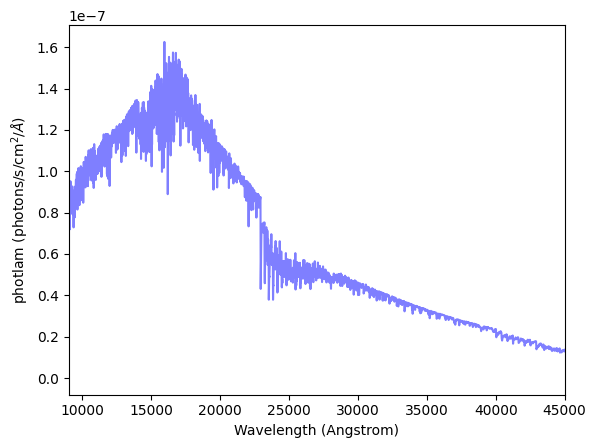

In [4]:
wvs = rsgspec.waveset
plt.plot(wvs, rsgspec(wvs), color = 'blue', alpha = 0.5)
plt.xlim(9000, 45000)
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel(r'photlam $(\text{photons}/\text{s}/\text{cm}^2/\AA)$')

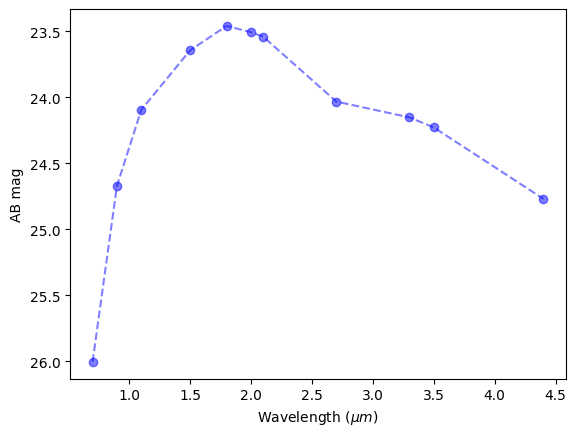

In [5]:
wvs = [float(i[1:3])/10 for i in filts]
mags = [rsgmag[flt].value for flt in filts]
plt.plot(wvs, mags, color = 'blue', alpha = 0.5, marker = 'o', linestyle = '--')
plt.xlabel(r'Wavelength (${\mu}m$)')
plt.ylabel('AB mag')
plt.gca().invert_yaxis()

In [208]:
filts = ['f070w', 'f090w', 'f115w', 'f150w', 'f182m', 'f200w', 'f210m', 'f277w', 'f335m', 'f356w', 'f444w']
syn_rsg = rsg_phot()
rsg_temps = np.linspace(3000, 5000, 11) * u.K
taus = np.linspace(0.01, 5, 11)
lums = np.linspace(4, 5, 11) * u.Lsun

f090w_mag, f150w_mag, f277w_mag = [], [], []

for i,lum in tqdm(enumerate(lums)):
    for j,tau in enumerate(taus):
        # for k,temp in enumerate(rsg_temps):
        try:
            rsgmag = syn_rsg.compute_rsg_mag(filts, tau, lum, 4000*u.K, 1000 * u.K, 16.07*u.Mpc)
            f090w_mag.append(rsgmag['f090w'].value)
            f150w_mag.append(rsgmag['f150w'].value)
            f277w_mag.append(rsgmag['f277w'].value)
        except:
            f090w_mag.append(np.nan)
            f090w_mag.append(np.nan)
            f277w_mag.append(np.nan)

f090w_mag, f150w_mag, f277w_mag  = np.array(f090w_mag), np.array(f150w_mag), np.array(f277w_mag)

11it [00:43,  3.93s/it]


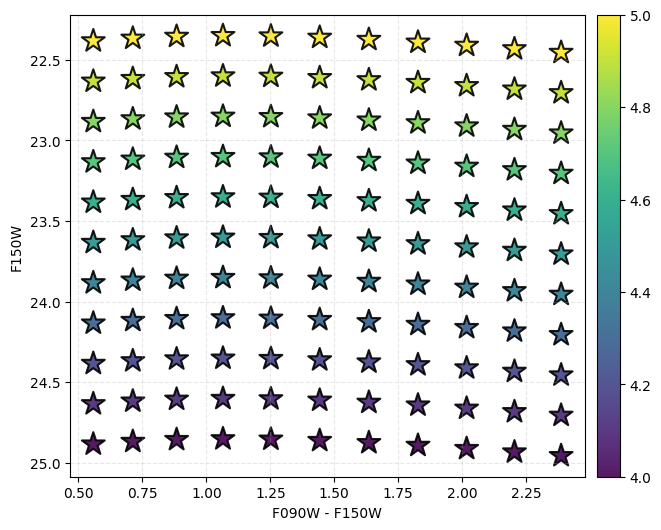

In [210]:
flt_1, flt_2 = 'f090w', 'f150w'
plt.figure(figsize = (8, 6))
plt.scatter(f090w_mag-f150w_mag, f150w_mag, marker='*', s=300, c=np.repeat(lums.value, 11),
            cmap='viridis', edgecolors='black', lw=1.5, alpha=0.9)
plt.colorbar(pad = 0.02)
plt.xlabel(f'{flt_1.upper()} - {flt_2.upper()}')
plt.ylabel(f'{flt_2.upper()}')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, linestyle='--')

In [176]:
mags = np.loadtxt('data/dolphot/ngc5643_mags.txt')
f090, f150, f277 = mags[0], mags[1], mags[2]

col = f090-f150
mag = f150-f277

In [174]:
def lin(x, m, c):
    return m*x+c

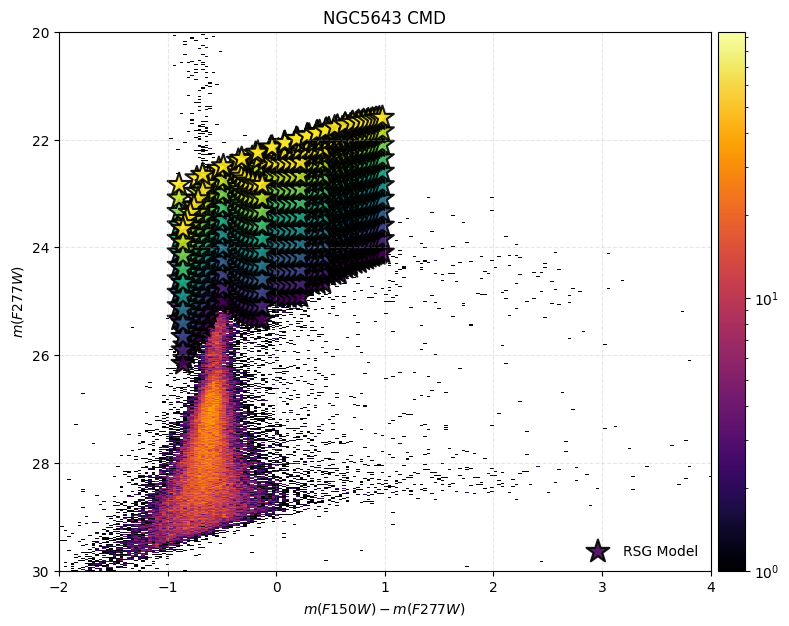

In [175]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F150W', 'F277W'

hist = ax.hist2d(col, mag, bins = 5000, norm = 'log', cmap = 'inferno')
ax.scatter(f150w_mag-f277w_mag, f277w_mag, marker='*', s=300, c=np.repeat(rsg_temps.value, 121),
            cmap='viridis', edgecolors='black', lw=1.5, alpha=0.9, label = 'RSG Model')

# ax.plot(np.linspace(-2, 4, 100), lin(np.linspace(-2, 4, 100), -13.33, 23), color = 'black', linestyle = '--', label = 'Massey+21')
# ax.plot(np.linspace(-2, 1.25, 100), lin(np.linspace(-2, 1.25, 100), -8, 30), color = 'cornflowerblue', linestyle = '--', label = 'Ren+21')
# ax.plot(np.linspace(1.25, 4, 100), lin(np.linspace(1.25, 4, 100), 0, 20), color = 'silver', linestyle = '--')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-2, 4)
ax.set_ylim(30, 20)
# ax.set_xlim(0, 4)
# ax.set_ylim(26, 22)
plt.show()

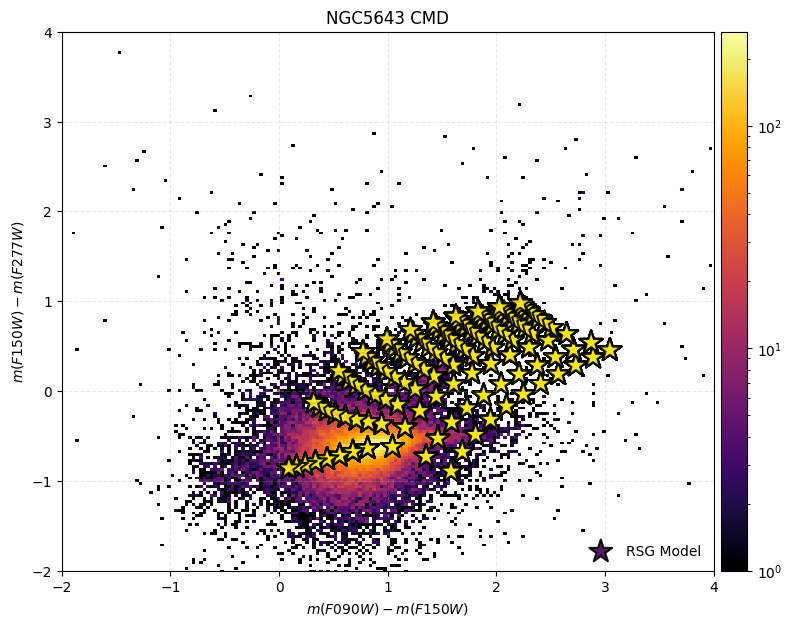

In [178]:
fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2, f3 = 'F090W', 'F150W', 'F277W'

hist = ax.hist2d(col, mag, bins = 5000, norm = 'log', cmap = 'inferno')
ax.scatter(f090w_mag-f150w_mag, f150w_mag-f277w_mag, marker='*', s=300, c=np.repeat(rsg_temps.value, 121),
            cmap='viridis', edgecolors='black', lw=1.5, alpha=0.9, label = 'RSG Model')

# ax.plot(np.linspace(-2, 4, 100), lin(np.linspace(-2, 4, 100), -13.33, 23), color = 'black', linestyle = '--', label = 'Massey+21')
# ax.plot(np.linspace(-2, 1.25, 100), lin(np.linspace(-2, 1.25, 100), -8, 30), color = 'cornflowerblue', linestyle = '--', label = 'Ren+21')
# ax.plot(np.linspace(1.25, 4, 100), lin(np.linspace(1.25, 4, 100), 0, 20), color = 'silver', linestyle = '--')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2}) - m({f3})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-2, 4)
ax.set_ylim(-2, 4)
plt.show()

In [204]:
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [205]:
pca = PCA(n_components=2)
ica = FastICA(n_components=2)
std_scaler = StandardScaler()
mmax_scaler = MinMaxScaler()

In [206]:
model_mags = np.vstack([f090w_mag, f150w_mag, f277w_mag])
stacked_mags = np.hstack([mags, model_mags])
scaled_mags = mmax_scaler.fit_transform(stacked_mags)
fit_input = scaled_mags
pca.fit(fit_input)

PCA(n_components=2)

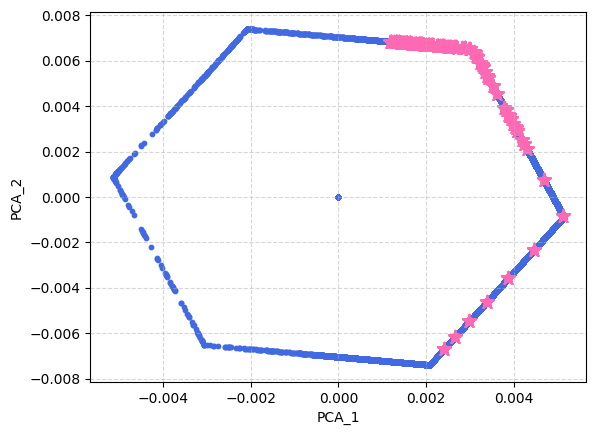

In [207]:
plt.scatter(pca.components_[0][:len(mags[0])], pca.components_[1][:len(mags[0])], s = 10, color = 'royalblue')
plt.scatter(pca.components_[0][len(mags[0]):], pca.components_[1][len(mags[0]):], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
# plt.xlim(-0.002, 0.002)
# plt.ylim(-0.005, 0.005)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

In [200]:
model_mags = np.vstack([f090w_mag, f150w_mag, f277w_mag])
stacked_mags = np.hstack([mags, model_mags])
scaled_mags = std_scaler.fit_transform(stacked_mags)
fit_input = stacked_mags
ica.fit(fit_input)

FastICA(n_components=2)

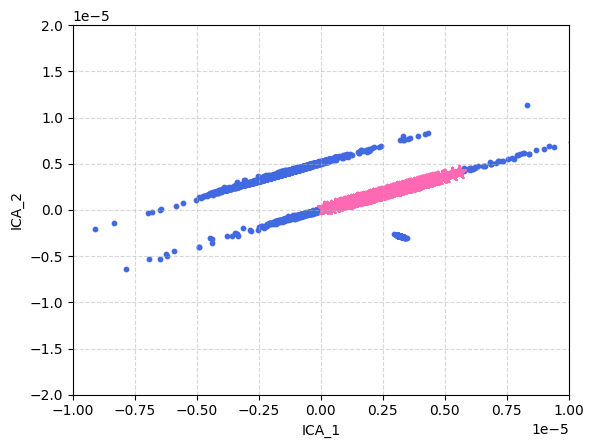

In [203]:
plt.scatter(ica.components_[0][:len(mags[0])], ica.components_[1][:len(mags[0])], s = 10, color = 'royalblue')
plt.scatter(ica.components_[0][len(mags[0]):], ica.components_[1][len(mags[0]):], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('ICA_1')
plt.ylabel('ICA_2')
plt.xlim(-1e-5, 1e-5)
plt.ylim(-2e-5, 2e-5)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

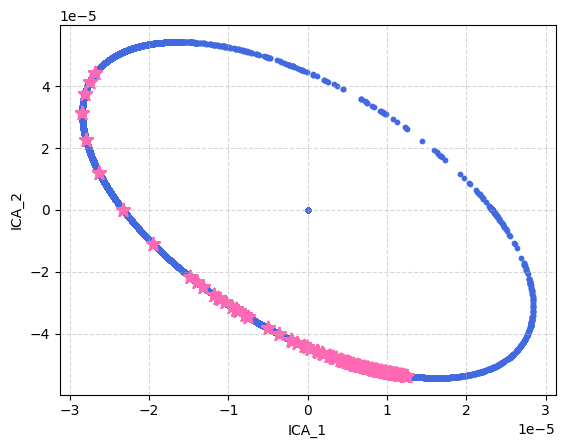

In [193]:
plt.scatter(ica.components_[0][:len(mags[0])], ica.components_[1][:len(mags[0])], s = 10, color = 'royalblue')
plt.scatter(ica.components_[0][len(mags[0]):], ica.components_[1][len(mags[0]):], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('ICA_1')
plt.ylabel('ICA_2')
# plt.xlim(-1e-5, 5e-6)
# plt.ylim(-2e-5, 2e-5)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()